# 05 — Model Preparation and Baseline Forecasts

## A common forecasting protocol for all later models

This notebook establishes the single source of truth for later ARIMA, Random Forest, XGBoost,
and hybrid experiments. It defines the target, forecast origin, eligible predictors,
chronological splits, baseline forecasts, and reusable evaluation functions.

It uses only `data/features/household_feature_dataset.csv`, the frozen Phase 2 output. It does
not recreate preprocessing or modify any Phase 1–2 artifact.

**Scope boundary:** this notebook implements benchmark rules and simple baselines only. It does
not implement any thesis forecasting model.


## 1. Imports and reproducible configuration


In [1]:
from pathlib import Path
from datetime import datetime
import importlib.util
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="colorblind",
    rc={"figure.dpi": 120, "savefig.dpi": 300},
)
COLORS = {
    "train": "#1F4E78",
    "validation": "#E9C46A",
    "test": "#C8553D",
    "teal": "#2A9D8F",
    "grey": "#6B7280",
}


## 2. Locate the project and load the frozen feature dataset


In [2]:
def locate_project_root(start: Path) -> Path:
    '''Locate the project without any machine-specific absolute path.'''
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "data" / "features" / "household_feature_dataset.csv").exists():
            return candidate
    raise FileNotFoundError(
        "Project root not found. Start Jupyter from the project root or notebooks directory."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
FEATURE_PATH = PROJECT_ROOT / "data" / "features" / "household_feature_dataset.csv"
MODEL_READY_DIR = PROJECT_ROOT / "data" / "model_ready"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
SRC_DIR = PROJECT_ROOT / "src"

for directory in (MODEL_READY_DIR, RESULTS_DIR, FIGURES_DIR, SRC_DIR):
    directory.mkdir(parents=True, exist_ok=True)

features = pd.read_csv(FEATURE_PATH).sort_values(["year", "region"]).reset_index(drop=True)
print(f"Input: {FEATURE_PATH.relative_to(PROJECT_ROOT)}")
print(f"Dimensions: {features.shape}")
display(features.head())


Input: data/features/household_feature_dataset.csv
Dimensions: (52, 31)


,year,region,annual_consumption_kwh,annual_cost_sar,winter_consumption_kwh,rest_of_year_consumption_kwh,winter_cost_sar,rest_of_year_cost_sar,average_cost_sar_per_kwh,winter_consumption_share_pct,selected_source,source_file,time_index,region_id,rest_to_winter_consumption_ratio,winter_to_rest_consumption_ratio,winter_cost_share_pct,consumption_lag_1,cost_lag_1,consumption_lag_2,cost_lag_2,consumption_rolling_mean_2,consumption_rolling_std_2,cost_rolling_mean_2,consumption_growth_lag_1_pct,cost_growth_lag_1_pct,winter_consumption_growth_lag_1_pct,rest_consumption_growth_lag_1_pct,region_historical_mean_consumption,region_historical_mean_cost,source_lineage
0,2019,Al-Bahah,"2,789,681,094.0000","836,616,522.0000","583,781,957.0000","2,205,899,137.0000","153,285,758.0000","683,330,764.0000",0.2999,20.9265,GASTAT original workbook,HouseholdEnergyStatistics2019En.xlsx,2,0,3.7786,0.2646,18.3221,3214577055,261429555,"3,078,128,993.3628","245,063,291.0192","3,146,353,024.1814","96,483,349.6634","253,246,423.0096",4.4328,6.6784,1.8743,5.0956,"3,146,353,024.1814","253,246,423.0096",GASTAT original workbook | HouseholdEnergyStat...
1,2019,Al-Jouf,"3,265,981,960.0000","1,122,461,237.0000","700,853,935.0000","2,565,128,025.0000","178,038,911.0000","944,422,326.0000",0.3437,21.4592,GASTAT original workbook,HouseholdEnergyStatistics2019En.xlsx,2,1,3.6600,0.2732,15.8615,5643290091,827752089,"5,588,687,122.2309","296,932,616.5539","5,615,988,606.6154","38,610,129.4896","562,342,352.7770",0.9770,178.7677,1.6382,0.8246,"5,615,988,606.6154","562,342,352.7770",GASTAT original workbook | HouseholdEnergyStat...
2,2019,Al-Qassim,"8,292,713,388.0000","2,418,167,922.0000","1,937,898,085.0000","6,354,815,303.0000","566,546,168.0000","1,851,621,754.0000",0.2916,23.3687,GASTAT original workbook,HouseholdEnergyStatistics2019En.xlsx,2,2,3.2792,0.3049,23.4287,10937520259,922177731,"10,384,493,122.6399","830,002,011.5630","10,661,006,690.8200","391,049,238.3004","876,089,871.2815",5.3255,11.1055,10.0167,4.4185,"10,661,006,690.8200","876,089,871.2815",GASTAT original workbook | HouseholdEnergyStat...
3,2019,Asir,"13,625,748,398.0000","4,170,282,160.0000","2,996,611,212.0000","10,629,137,186.0000","675,309,400.0000","3,494,972,760.0000",0.3061,21.9923,GASTAT original workbook,HouseholdEnergyStatistics2019En.xlsx,2,3,3.5471,0.2819,16.1934,24780198852,3196672520,"24,610,534,454.8141","2,245,157,639.9591","24,695,366,653.4071","119,970,845.7760","2,720,915,079.9795",0.6894,42.3808,1.1791,0.5902,"24,695,366,653.4071","2,720,915,079.9795",GASTAT original workbook | HouseholdEnergyStat...
4,2019,Eastern Region,"32,484,475,163.0000","11,329,072,150.0000","4,294,128,877.0000","28,190,346,286.0000","952,025,741.0000","10,377,046,409.0000",0.3488,13.2190,GASTAT original workbook,HouseholdEnergyStatistics2019En.xlsx,2,4,6.5649,0.1523,8.4034,36141733496,3494634736,"35,990,505,143.6888","3,524,878,638.0996","36,066,119,319.8444","106,934,593.4269","3,509,756,687.0498",0.4202,-0.8580,1.0379,0.3144,"36,066,119,319.8444","3,509,756,687.0498",GASTAT original workbook | HouseholdEnergyStat...


## 3. Dataset inspection and quality gate

Required fields must be complete, keys must be unique, and numeric values must be finite. The
notebook stops before creating model-ready data if any condition fails.


In [3]:
key_columns = ["year", "region"]
target_column = "annual_consumption_kwh"

inspection = pd.DataFrame({
    "dtype": features.dtypes.astype(str),
    "missing_values": features.isna().sum(),
    "unique_values": features.nunique(dropna=False),
})
display(inspection)

duplicate_keys = int(features.duplicated(key_columns).sum())
numeric_columns = features.select_dtypes(include=[np.number]).columns
infinite_values = int(np.isinf(features[numeric_columns].to_numpy(dtype=float)).sum())
missing_values = int(features.isna().sum().sum())

quality_checks = pd.DataFrame([
    ("rows", len(features)),
    ("columns", features.shape[1]),
    ("years", features["year"].nunique()),
    ("regions", features["region"].nunique()),
    ("missing_values", missing_values),
    ("duplicate_region_year_keys", duplicate_keys),
    ("infinite_numeric_values", infinite_values),
    ("nonpositive_target_values", int((features[target_column] <= 0).sum())),
], columns=["check", "value"])
display(quality_checks)

if missing_values or duplicate_keys or infinite_values:
    raise ValueError("The frozen feature dataset failed the model-preparation quality gate.")
if (features[target_column] <= 0).any():
    raise ValueError("The forecasting target contains an impossible non-positive value.")


,dtype,missing_values,unique_values
year,int64,0,4
region,object,0,13
annual_consumption_kwh,float64,0,52
annual_cost_sar,float64,0,52
winter_consumption_kwh,float64,0,52
rest_of_year_consumption_kwh,float64,0,52
winter_cost_sar,float64,0,52
rest_of_year_cost_sar,float64,0,52
average_cost_sar_per_kwh,float64,0,52
winter_consumption_share_pct,float64,0,52


,check,value
0,rows,52
1,columns,31
2,years,4
3,regions,13
4,missing_values,0
5,duplicate_region_year_keys,0
6,infinite_numeric_values,0
7,nonpositive_target_values,0


## 4. Forecasting target and prediction objective

| Element | Definition |
|---|---|
| Target | `annual_consumption_kwh` |
| Forecasting unit | One administrative region in one target year |
| Geographic resolution | 13 Saudi administrative regions |
| Temporal resolution | Annual |
| Forecast origin | End of year *t−1* |
| Forecast horizon | One year ahead |
| Objective | Predict household electricity consumption for region *r* in year *t* using information available no later than *t−1* |

This definition works for statistical, machine-learning, and hybrid methods. The target is
strictly positive, so MAE, RMSE, MAPE, and R² are all defined for each holdout year.


## 5. Complete feature classification


In [4]:
def classify_feature(column: str) -> str:
    if column in {"selected_source", "source_file", "source_lineage"}:
        return "Metadata / lineage"
    if column in {"region", "region_id"}:
        return "Identifier"
    if column in {"year", "time_index"}:
        return "Time"
    if "rolling_" in column:
        return "Rolling statistic"
    if "growth_" in column:
        return "Growth"
    if "lag_" in column:
        return "Lag"
    if column.startswith("region_historical_"):
        return "Regional historical"
    if "ratio" in column or "share_pct" in column or "per_kwh" in column:
        return "Ratio / intensity"
    if "cost" in column:
        return "Cost"
    if "consumption" in column:
        return "Consumption"
    return "Other engineered"


feature_inventory = pd.DataFrame({
    "variable": features.columns,
    "category": [classify_feature(column) for column in features.columns],
    "dtype": features.dtypes.astype(str).values,
})
display(feature_inventory)
display(feature_inventory.groupby("category").size().rename("variable_count").to_frame())


,variable,category,dtype
0,year,Time,int64
1,region,Identifier,object
2,annual_consumption_kwh,Consumption,float64
3,annual_cost_sar,Cost,float64
4,winter_consumption_kwh,Consumption,float64
5,rest_of_year_consumption_kwh,Consumption,float64
6,winter_cost_sar,Cost,float64
7,rest_of_year_cost_sar,Cost,float64
8,average_cost_sar_per_kwh,Ratio / intensity,float64
9,winter_consumption_share_pct,Ratio / intensity,float64


,variable_count
category,
Consumption,3
Cost,3
Growth,4
Identifier,2
Lag,4
Metadata / lineage,3
Ratio / intensity,5
Regional historical,2
Rolling statistic,3


## 6. Model input selection and leakage policy

At the end of year *t−1*, current-year consumption, cost, and ratios are unknown. They are
therefore excluded even when correlated with the target. Metadata is excluded because it
describes provenance rather than the electricity process. `region_id` is excluded because its
integer values are arbitrary labels and would falsely impose an ordinal distance.

`year` and `region` remain in exported X files as **keys**, not numerical predictors. Later
model notebooks must form a numerical matrix from `predictor_columns`; region-aware methods may
encode the `region` key explicitly without changing the observations or splits.


In [5]:
predictor_columns = [
    "time_index",
    "consumption_lag_1",
    "consumption_lag_2",
    "cost_lag_1",
    "cost_lag_2",
    "consumption_rolling_mean_2",
    "consumption_rolling_std_2",
    "cost_rolling_mean_2",
    "consumption_growth_lag_1_pct",
    "cost_growth_lag_1_pct",
    "winter_consumption_growth_lag_1_pct",
    "rest_consumption_growth_lag_1_pct",
    "region_historical_mean_consumption",
    "region_historical_mean_cost",
]

excluded_reasons = {
    "annual_consumption_kwh": "Forecasting target; cannot also be a predictor.",
    "annual_cost_sar": "Current-year outcome unavailable at the end of t−1.",
    "winter_consumption_kwh": "Current-year target component; deterministically leaks target information.",
    "rest_of_year_consumption_kwh": "Current-year target component; deterministically leaks target information.",
    "winter_cost_sar": "Current-year outcome unavailable at forecast origin.",
    "rest_of_year_cost_sar": "Current-year outcome unavailable at forecast origin.",
    "average_cost_sar_per_kwh": "Uses current-year target in its denominator and current-year cost.",
    "winter_consumption_share_pct": "Calculated from current-year target components.",
    "rest_to_winter_consumption_ratio": "Calculated from current-year consumption components.",
    "winter_to_rest_consumption_ratio": "Calculated from current-year consumption components.",
    "winter_cost_share_pct": "Calculated from current-year costs.",
    "selected_source": "Source-lineage metadata, not a forecasting signal.",
    "source_file": "Source-lineage metadata, not a forecasting signal.",
    "source_lineage": "Source-lineage metadata, not a forecasting signal.",
    "region_id": "Arbitrary nominal code; numeric use would impose false ordinality.",
}

expected_columns = set(key_columns + [target_column] + predictor_columns + list(excluded_reasons))
unclassified = sorted(set(features.columns) - expected_columns)
if unclassified:
    raise ValueError(f"Variables without a documented selection decision: {unclassified}")

selection_inventory = feature_inventory.copy()
selection_inventory["role"] = selection_inventory["variable"].map(
    lambda column: (
        "Key (not numeric predictor)" if column in key_columns
        else "Target" if column == target_column
        else "Predictor" if column in predictor_columns
        else "Excluded"
    )
)
selection_inventory["decision_reason"] = selection_inventory["variable"].map(
    lambda column: (
        "Region-year observation key retained for alignment and grouping."
        if column in key_columns
        else "One-year-ahead regional household consumption target."
        if column == target_column
        else "Known by forecast origin and scientifically relevant historical predictor."
        if column in predictor_columns
        else excluded_reasons[column]
    )
)
display(selection_inventory)

X_features = features[key_columns + predictor_columns].copy()
y_target = features[key_columns + [target_column]].copy()

assert X_features[key_columns].equals(y_target[key_columns])
assert not X_features.isna().any().any()
assert not y_target.isna().any().any()


,variable,category,dtype,role,decision_reason
0,year,Time,int64,Key (not numeric predictor),Region-year observation key retained for align...
1,region,Identifier,object,Key (not numeric predictor),Region-year observation key retained for align...
2,annual_consumption_kwh,Consumption,float64,Target,One-year-ahead regional household consumption ...
3,annual_cost_sar,Cost,float64,Excluded,Current-year outcome unavailable at the end of...
4,winter_consumption_kwh,Consumption,float64,Excluded,Current-year target component; deterministical...
5,rest_of_year_consumption_kwh,Consumption,float64,Excluded,Current-year target component; deterministical...
6,winter_cost_sar,Cost,float64,Excluded,Current-year outcome unavailable at forecast o...
7,rest_of_year_cost_sar,Cost,float64,Excluded,Current-year outcome unavailable at forecast o...
8,average_cost_sar_per_kwh,Ratio / intensity,float64,Excluded,Uses current-year target in its denominator an...
9,winter_consumption_share_pct,Ratio / intensity,float64,Excluded,Calculated from current-year target components.


## 7. Chronological train, validation, and test protocol

The model-ready table covers 2019–2022. The protocol uses:

- **Training:** 2019–2020 (26 region-year observations)
- **Validation:** 2021 (13 observations)
- **Testing:** 2022 (13 observations)
- **Forecast horizon:** one year

Random splitting is invalid because it would allow later years to inform predictions for
earlier years and would place observations sharing the same national context across partitions.
The 2022 test year remains untouched during future model selection. After a model is selected
using 2021, a future modeling notebook may refit that fixed specification through 2021 before
the single 2022 evaluation; it must not tune against 2022.


In [6]:
TRAIN_YEARS = [2019, 2020]
VALIDATION_YEARS = [2021]
TEST_YEARS = [2022]
FORECAST_HORIZON_YEARS = 1

split_by_year = {
    "train": TRAIN_YEARS,
    "validation": VALIDATION_YEARS,
    "test": TEST_YEARS,
}

def select_years(frame: pd.DataFrame, years: list[int]) -> pd.DataFrame:
    return frame.loc[frame["year"].isin(years)].sort_values(key_columns).reset_index(drop=True)


model_frame = X_features.merge(y_target, on=key_columns, validate="one_to_one")
split_frames = {
    name: select_years(model_frame, years)
    for name, years in split_by_year.items()
}
X_splits = {
    name: frame[key_columns + predictor_columns].copy()
    for name, frame in split_frames.items()
}
y_splits = {
    name: frame[key_columns + [target_column]].copy()
    for name, frame in split_frames.items()
}

for name in split_by_year:
    assert X_splits[name][key_columns].equals(y_splits[name][key_columns])
    assert set(split_frames[name]["year"]) == set(split_by_year[name])

split_summary = pd.DataFrame([
    {
        "split": name,
        "years": ", ".join(map(str, years)),
        "rows": len(split_frames[name]),
        "regions": split_frames[name]["region"].nunique(),
    }
    for name, years in split_by_year.items()
])
display(split_summary)


,split,years,rows,regions
0,train,"2019, 2020",26,13
1,validation,2021,13,13
2,test,2022,13,13


## 8. Export the single source-of-truth model-ready datasets


In [7]:
X_features.to_csv(MODEL_READY_DIR / "X_features.csv", index=False, float_format="%.15g")
y_target.to_csv(MODEL_READY_DIR / "y_target.csv", index=False, float_format="%.15g")

for name in ("train", "validation", "test"):
    split_frames[name].to_csv(
        MODEL_READY_DIR / f"{name}.csv", index=False, float_format="%.15g"
    )
    X_splits[name].to_csv(
        MODEL_READY_DIR / f"X_{name}.csv", index=False, float_format="%.15g"
    )
    y_splits[name].to_csv(
        MODEL_READY_DIR / f"y_{name}.csv", index=False, float_format="%.15g"
    )

print("Saved 11 requested model-ready CSV files.")


Saved 11 requested model-ready CSV files.


## 9. Reusable evaluation module

The module below is written to `src/evaluation.py`. Future notebooks must import its
`evaluate_regression` or `evaluate_prediction_frame` functions instead of redefining metrics.

- **MAE:** mean absolute error; same unit as the target.
- **RMSE:** square root of mean squared error; penalizes large errors.
- **MAPE:** mean absolute percentage error; scale-normalized and interpretable because actual
  consumption is strictly positive.
- **R²:** proportion of cross-sectional variation explained within the evaluated holdout year;
  negative values indicate performance below the holdout mean benchmark.


In [8]:
EVALUATION_MODULE = '''# Reusable regression evaluation for Saudi household forecasts.

from __future__ import annotations

import numpy as np
import pandas as pd


METRIC_COLUMNS = ["MAE", "RMSE", "MAPE", "R2"]


def evaluate_regression(y_true, y_pred, model_name=None, split=None):
    'Return MAE, RMSE, MAPE (%), and R² with strict finite-value checks.'
    actual = np.asarray(y_true, dtype=float)
    predicted = np.asarray(y_pred, dtype=float)
    if actual.shape != predicted.shape:
        raise ValueError("Actual and predicted arrays must have identical shapes.")
    if actual.size == 0:
        raise ValueError("Evaluation arrays cannot be empty.")
    if not np.isfinite(actual).all() or not np.isfinite(predicted).all():
        raise ValueError("Evaluation arrays must contain only finite values.")
    if np.any(actual == 0):
        raise ValueError("MAPE is undefined when an actual target equals zero.")

    residual = actual - predicted
    mae = float(np.mean(np.abs(residual)))
    rmse = float(np.sqrt(np.mean(residual ** 2)))
    mape = float(np.mean(np.abs(residual / actual)) * 100)
    denominator = float(np.sum((actual - np.mean(actual)) ** 2))
    r2 = float(1 - np.sum(residual ** 2) / denominator) if denominator > 0 else np.nan

    result = {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}
    if model_name is not None:
        result["model"] = model_name
    if split is not None:
        result["split"] = split
    return result


def evaluate_prediction_frame(frame, actual_column, prediction_columns, split=None):
    'Evaluate multiple named prediction columns using one consistent implementation.'
    records = []
    for column in prediction_columns:
        records.append(
            evaluate_regression(
                frame[actual_column],
                frame[column],
                model_name=column,
                split=split,
            )
        )
    return pd.DataFrame(records)
'''

EVALUATION_PATH = SRC_DIR / "evaluation.py"
EVALUATION_PATH.write_text(EVALUATION_MODULE, encoding="utf-8")

spec = importlib.util.spec_from_file_location("saudi_evaluation", EVALUATION_PATH)
evaluation = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = evaluation
spec.loader.exec_module(evaluation)
print(f"Reusable module: {EVALUATION_PATH.relative_to(PROJECT_ROOT)}")


Reusable module: src/evaluation.py


## 10. Baseline forecast definitions

All baselines forecast each region independently at a one-year horizon.

| Baseline | Formula for region *r*, year *t* | Strength | Weakness |
|---|---|---|---|
| Naive | ŷᵣ,ₜ = yᵣ,ₜ₋₁ | Transparent reference | Cannot anticipate trend reversals |
| Persistence | ŷᵣ,ₜ = `consumption_lag_1` | Operational “no change” benchmark | For annual data, mathematically identical to naive |
| Historical mean | ŷᵣ,ₜ = mean(yᵣ,ₛ for s < t) | Stable against short-term noise | Adapts slowly to structural change |
| Two-year moving average | ŷᵣ,ₜ = mean(yᵣ,ₜ₋₁, yᵣ,ₜ₋₂) | Uses recent level and smooths noise | Can lag rapid changes |

**Seasonal naive is not implemented.** The target is annual and the model-ready data contain
no repeated within-year seasonal periods. A seasonal lag at annual frequency would require a
multi-year seasonal cycle that is neither defined nor supported by four target years. Applying
seasonal naive would therefore be mislabeled and scientifically unjustified.

Naive and persistence are deliberately both reported because they were requested and future
papers often use the terms differently. Their numerical equality is checked rather than hidden.


In [9]:
baseline_columns = {
    "Naive": "baseline_naive",
    "Persistence": "baseline_persistence",
    "Historical Mean": "baseline_historical_mean",
    "Moving Average (2-year)": "baseline_moving_average_2",
}

def generate_baseline_predictions(frame: pd.DataFrame, split_name: str) -> pd.DataFrame:
    output = frame[key_columns + [target_column]].copy()
    output["split"] = split_name
    output["baseline_naive"] = frame["consumption_lag_1"].to_numpy()
    output["baseline_persistence"] = frame["consumption_lag_1"].to_numpy()
    output["baseline_historical_mean"] = frame[
        "region_historical_mean_consumption"
    ].to_numpy()
    output["baseline_moving_average_2"] = frame[
        "consumption_rolling_mean_2"
    ].to_numpy()
    if output[list(baseline_columns.values())].isna().any().any():
        raise ValueError("A baseline prediction contains a missing value.")
    return output


validation_predictions = generate_baseline_predictions(
    split_frames["validation"], "validation"
)
test_predictions = generate_baseline_predictions(split_frames["test"], "test")
baseline_predictions = pd.concat(
    [validation_predictions, test_predictions], ignore_index=True
)

assert np.array_equal(
    baseline_predictions["baseline_naive"].to_numpy(),
    baseline_predictions["baseline_persistence"].to_numpy(),
)
display(baseline_predictions.head())


,year,region,annual_consumption_kwh,split,baseline_naive,baseline_persistence,baseline_historical_mean,baseline_moving_average_2
0,2021,Al-Bahah,"1,832,647,730.0000",validation,2303504309,2303504309,"2,846,472,862.8407","2,546,592,701.5000"
1,2021,Al-Jouf,"1,495,169,225.0000",validation,2593704416,2593704416,"4,272,915,897.3077","2,929,843,188.0000"
2,2021,Al-Qassim,"10,685,966,202.0000",validation,10038115978,10038115978,"9,913,210,686.9100","9,165,414,683.0000"
3,2021,Asir,"5,949,106,568.0000",validation,10832588845,10832588845,"18,462,267,637.4535","12,229,168,621.5000"
4,2021,Eastern Region,"18,541,505,095.0000",validation,25039529172,25039529172,"32,414,060,743.6722","28,762,002,167.5000"


## 11. Apply the common evaluation framework


In [10]:
metric_records = []
for split_name, prediction_frame in [
    ("validation", validation_predictions),
    ("test", test_predictions),
]:
    for model_label, prediction_column in baseline_columns.items():
        metrics = evaluation.evaluate_regression(
            prediction_frame[target_column],
            prediction_frame[prediction_column],
            model_name=model_label,
            split=split_name,
        )
        metrics["n_observations"] = len(prediction_frame)
        metric_records.append(metrics)

baseline_results = pd.DataFrame(metric_records)[
    ["split", "model", "n_observations", "MAE", "RMSE", "MAPE", "R2"]
].sort_values(["split", "RMSE", "model"]).reset_index(drop=True)
baseline_results.to_csv(RESULTS_DIR / "baseline_results.csv", index=False, float_format="%.15g")
display(baseline_results)


,split,model,n_observations,MAE,RMSE,MAPE,R2
0,test,Moving Average (2-year),13,"2,323,903,878.1641","4,178,515,931.4096",14.9280,0.9226
1,test,Naive,13,"3,050,746,607.3179","4,773,581,114.1593",23.6559,0.8990
2,test,Persistence,13,"3,050,746,607.3179","4,773,581,114.1593",23.6559,0.8990
3,test,Historical Mean,13,"3,500,664,048.2434","5,664,021,617.8561",26.6686,0.8578
4,validation,Naive,13,"1,682,348,599.0769","2,547,485,217.3830",27.1093,0.9809
5,validation,Persistence,13,"1,682,348,599.0769","2,547,485,217.3830",27.1093,0.9809
6,validation,Moving Average (2-year),13,"3,003,103,114.3846","4,415,550,204.8128",38.6645,0.9425
7,validation,Historical Mean,13,"3,852,466,023.7927","5,782,286,158.5502",65.9955,0.9014


## 12. Publication-quality protocol visualizations


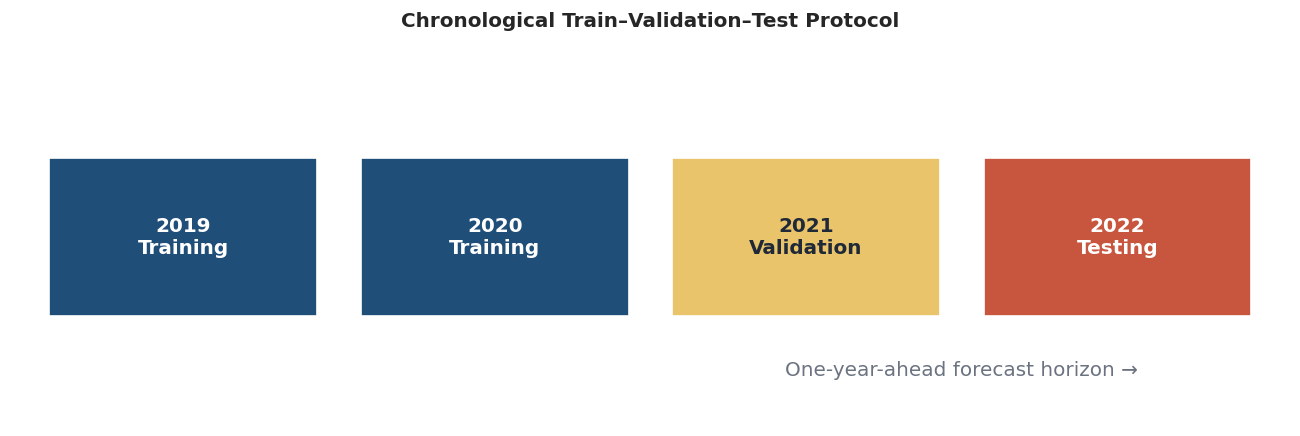

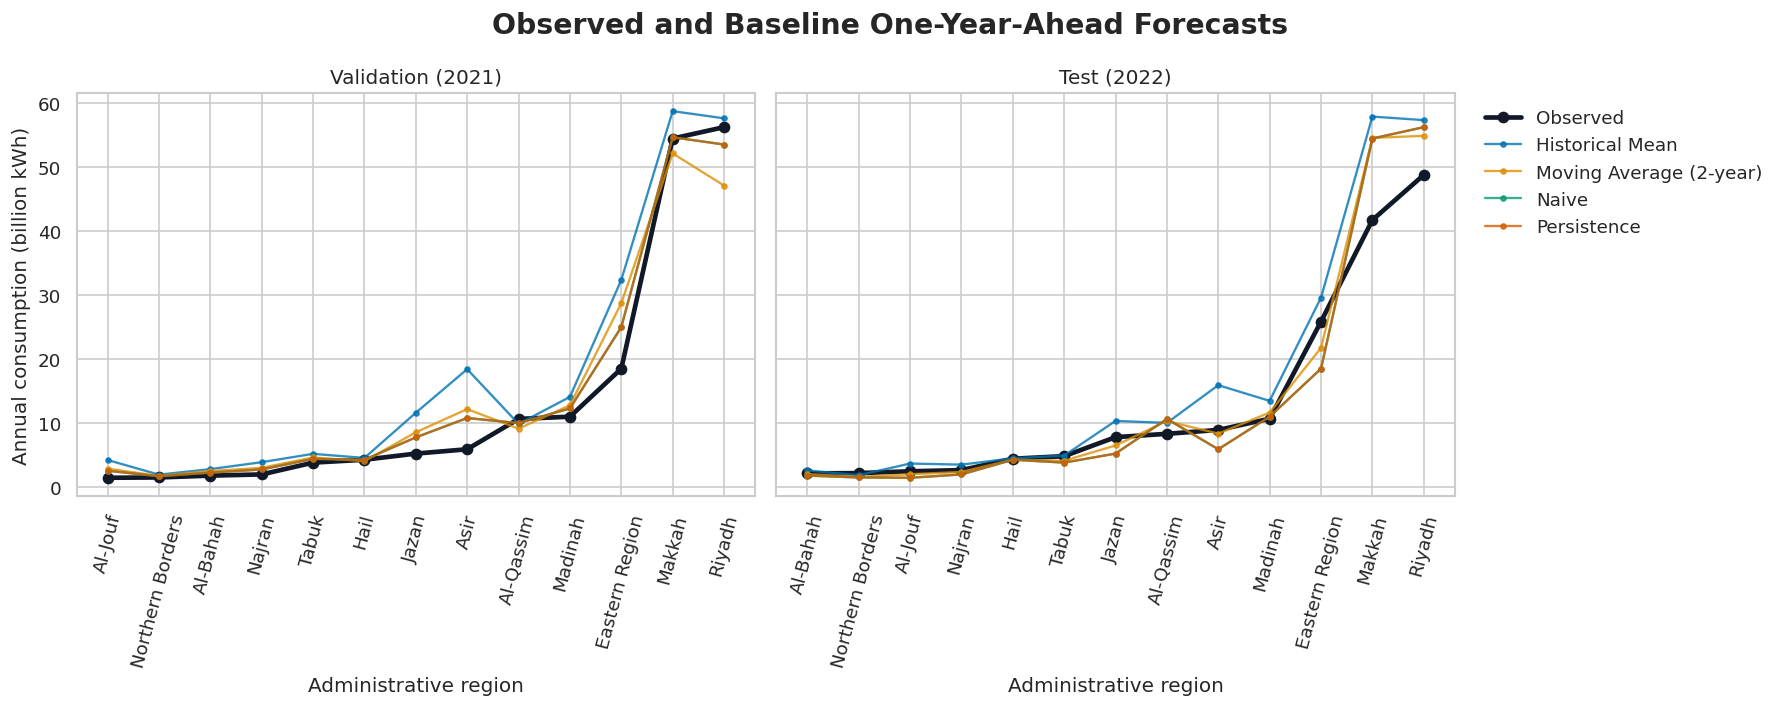

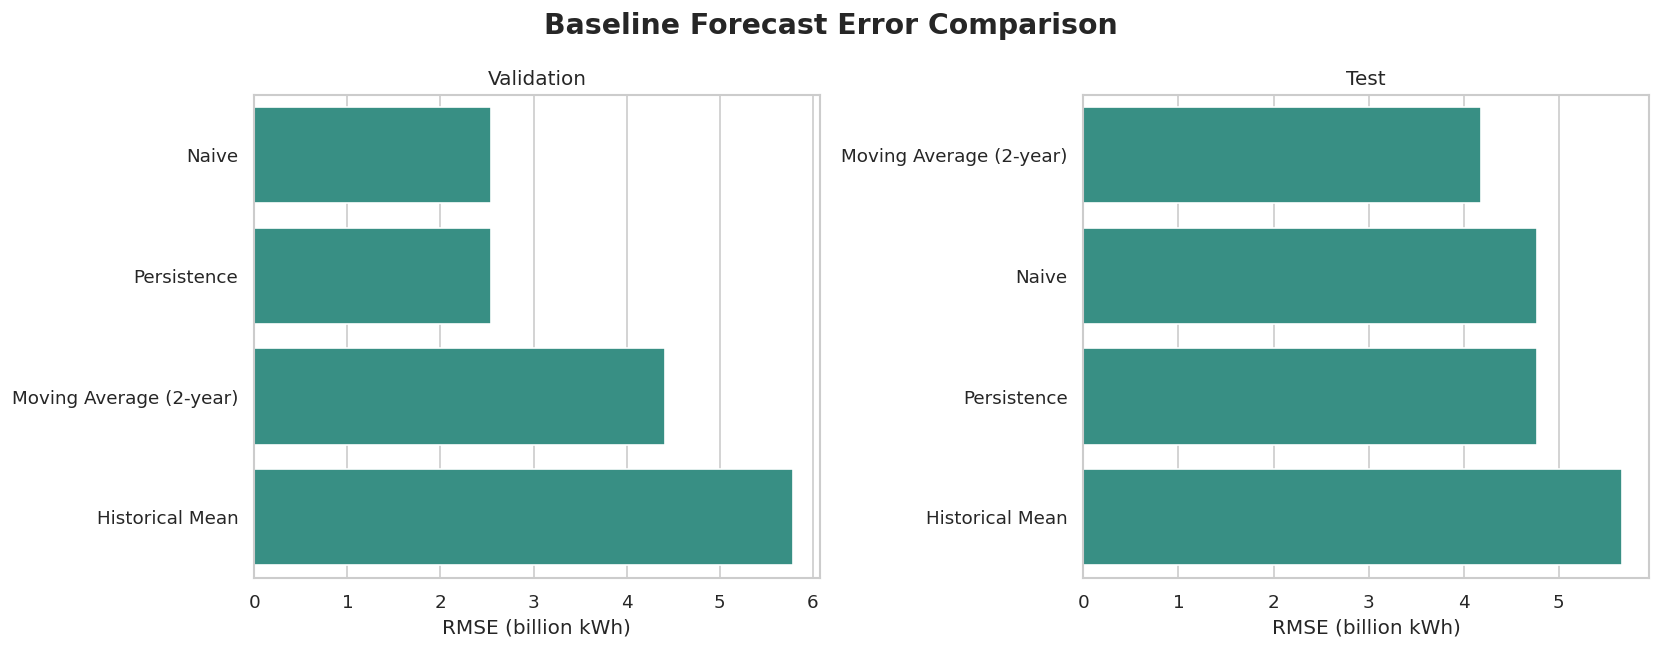

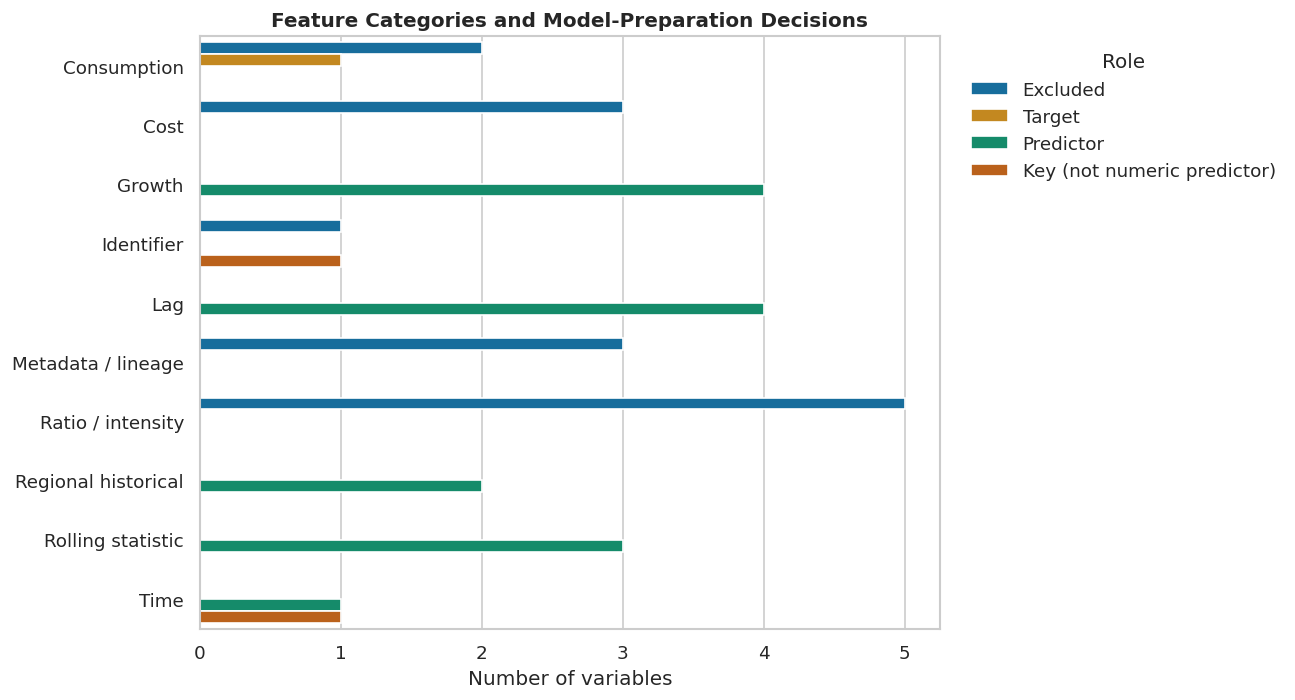

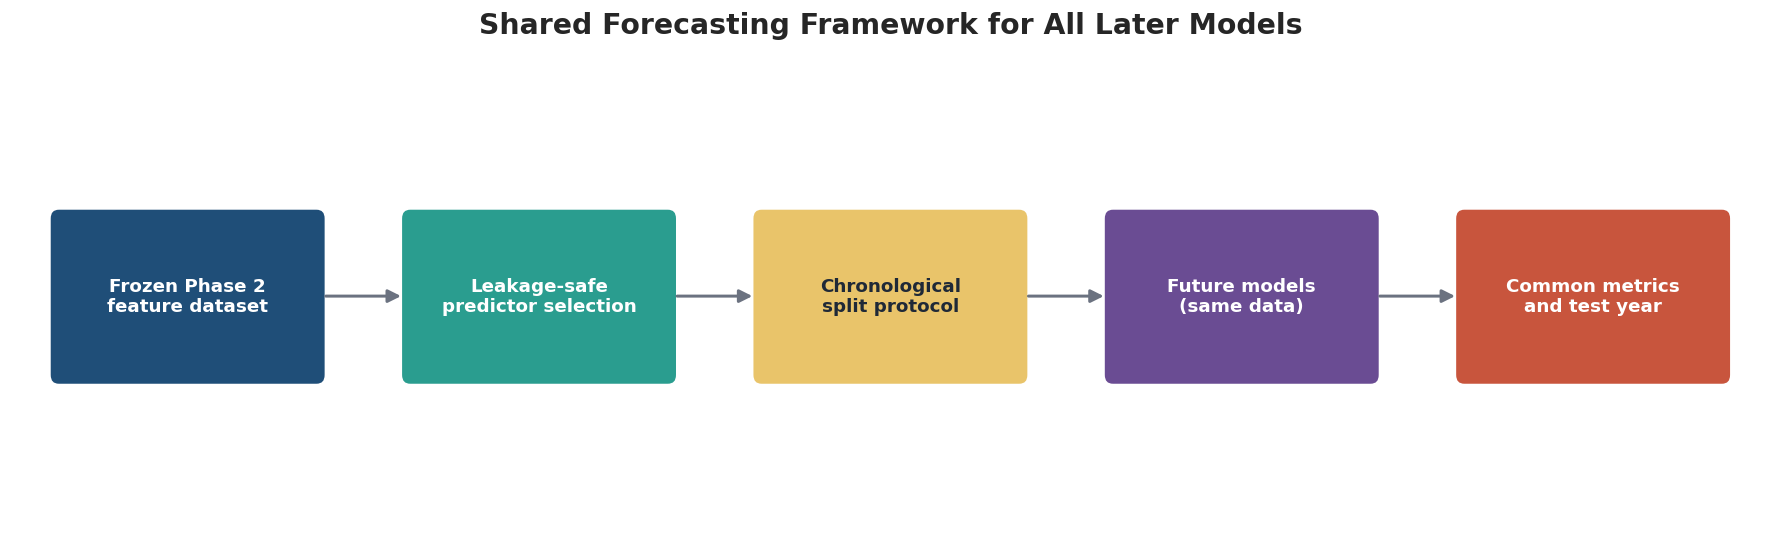

In [11]:
# Figure 1: chronological split
fig, ax = plt.subplots(figsize=(11, 3.8))
year_split = pd.DataFrame({
    "year": [2019, 2020, 2021, 2022],
    "split": ["Training", "Training", "Validation", "Testing"],
})
color_map = {
    "Training": COLORS["train"],
    "Validation": COLORS["validation"],
    "Testing": COLORS["test"],
}
for row in year_split.itertuples():
    ax.barh(0, 0.86, left=row.year - 0.43, color=color_map[row.split],
            edgecolor="white", height=0.55)
    ax.text(row.year, 0, f"{row.year}\n{row.split}", ha="center", va="center",
            color="white" if row.split != "Validation" else "#1F2937", weight="bold")
ax.set_xlim(2018.45, 2022.55)
ax.set_ylim(-0.65, 0.65)
ax.set_yticks([])
ax.set_xticks([])
ax.set_title("Chronological Train–Validation–Test Protocol", weight="bold", pad=14)
ax.text(2021.5, -0.48, "One-year-ahead forecast horizon →", ha="center",
        color=COLORS["grey"])
sns.despine(ax=ax, left=True, bottom=True)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "train_validation_test_split.png", bbox_inches="tight")
plt.show()

# Figure 2: observed versus baseline predictions
plot_predictions = baseline_predictions.melt(
    id_vars=["split", "year", "region", target_column],
    value_vars=list(baseline_columns.values()),
    var_name="baseline", value_name="prediction",
)
label_map = {value: key for key, value in baseline_columns.items()}
plot_predictions["baseline"] = plot_predictions["baseline"].map(label_map)
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for ax, split_name in zip(axes, ["validation", "test"]):
    subset = plot_predictions[plot_predictions["split"].eq(split_name)]
    order = (
        subset[["region", target_column]].drop_duplicates()
        .sort_values(target_column)["region"].tolist()
    )
    actual = subset[["region", target_column]].drop_duplicates().set_index("region").loc[order]
    ax.plot(order, actual[target_column] / 1e9, color="#111827", marker="o",
            linewidth=2.8, label="Observed")
    for baseline_name, group in subset.groupby("baseline"):
        values = group.set_index("region").loc[order]
        ax.plot(order, values["prediction"] / 1e9, marker=".", linewidth=1.4,
                alpha=0.8, label=baseline_name)
    ax.set_title(f"{split_name.title()} ({int(subset['year'].iloc[0])})")
    ax.tick_params(axis="x", rotation=75)
    ax.set_xlabel("Administrative region")
axes[0].set_ylabel("Annual consumption (billion kWh)")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.suptitle("Observed and Baseline One-Year-Ahead Forecasts", fontsize=17, weight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "baseline_predictions.png", bbox_inches="tight")
plt.show()

# Figure 3: baseline error comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, split_name in zip(axes, ["validation", "test"]):
    subset = baseline_results[baseline_results["split"].eq(split_name)].copy()
    subset["RMSE_billion_kwh"] = subset["RMSE"] / 1e9
    sns.barplot(data=subset, x="RMSE_billion_kwh", y="model",
                color=COLORS["teal"], ax=ax)
    ax.set_title(split_name.title())
    ax.set_xlabel("RMSE (billion kWh)")
    ax.set_ylabel("")
fig.suptitle("Baseline Forecast Error Comparison", fontsize=17, weight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "baseline_model_comparison.png", bbox_inches="tight")
plt.show()

# Figure 4: feature groups and selection status
feature_group_counts = (
    selection_inventory.groupby(["category", "role"]).size()
    .rename("count").reset_index()
)
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=feature_group_counts, y="category", x="count", hue="role", ax=ax)
ax.set_title("Feature Categories and Model-Preparation Decisions", weight="bold")
ax.set_xlabel("Number of variables")
ax.set_ylabel("")
ax.legend(title="Role", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "feature_groups.png", bbox_inches="tight")
plt.show()

# Figure 5: reusable forecasting framework
fig, ax = plt.subplots(figsize=(15, 4.8))
ax.set_xlim(0, 15)
ax.set_ylim(0, 4)
ax.axis("off")
nodes = [
    (0.4, "Frozen Phase 2\nfeature dataset", COLORS["train"]),
    (3.4, "Leakage-safe\npredictor selection", COLORS["teal"]),
    (6.4, "Chronological\nsplit protocol", COLORS["validation"]),
    (9.4, "Future models\n(same data)", "#6A4C93"),
    (12.4, "Common metrics\nand test year", COLORS["test"]),
]
for x, label, color in nodes:
    patch = FancyBboxPatch(
        (x, 1.35), 2.2, 1.25,
        boxstyle="round,pad=0.08,rounding_size=0.08",
        facecolor=color, edgecolor="white", linewidth=1.5,
    )
    ax.add_patch(patch)
    ax.text(x + 1.1, 1.98, label, ha="center", va="center",
            color="white" if color != COLORS["validation"] else "#1F2937",
            weight="bold", fontsize=11)
for index in range(len(nodes) - 1):
    start = nodes[index][0] + 2.25
    end = nodes[index + 1][0] - 0.05
    ax.add_patch(FancyArrowPatch(
        (start, 1.98), (end, 1.98), arrowstyle="-|>",
        mutation_scale=16, linewidth=1.8, color=COLORS["grey"],
    ))
ax.set_title("Shared Forecasting Framework for All Later Models", fontsize=17, weight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "forecasting_framework.png", bbox_inches="tight")
plt.show()


## 13. Reproducible methodology reports


In [12]:
def markdown_table(frame: pd.DataFrame) -> str:
    headers = [str(column) for column in frame.columns]
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |",
    ]
    for row in frame.itertuples(index=False, name=None):
        lines.append("| " + " | ".join(str(value) for value in row) + " |")
    return "\n".join(lines)


feature_selection_lines = [
    "# Feature Selection Report", "",
    f"Generated: {datetime.now().astimezone().isoformat(timespec='seconds')}", "",
    "## Forecast origin", "",
    "Predict annual regional household consumption for year t using information available "
    "by the end of t−1.", "",
    "## Complete variable decisions", "",
    markdown_table(selection_inventory[["variable", "category", "role", "decision_reason"]]),
    "", "## Predictor contract", "",
    "The exported X files contain `year` and `region` alignment keys followed by these "
    "approved predictors:", "",
]
feature_selection_lines.extend([f"- `{column}`" for column in predictor_columns])
(RESULTS_DIR / "feature_selection_report.md").write_text(
    "\n".join(feature_selection_lines) + "\n", encoding="utf-8"
)

protocol_lines = [
    "# Evaluation Protocol", "",
    f"Generated: {datetime.now().astimezone().isoformat(timespec='seconds')}", "",
    "## Forecast definition", "",
    "- Target: `annual_consumption_kwh`",
    "- Unit: administrative region × target year",
    "- Horizon: one year ahead",
    "- Forecast origin: end of t−1", "",
    "## Fixed chronological partitions", "",
    "- Training: 2019–2020",
    "- Validation: 2021",
    "- Final test: 2022", "",
    "Random splitting is prohibited because it leaks later temporal regimes into earlier "
    "forecasts and mixes region-year observations from the same national context.", "",
    "## Model-development rule", "",
    "Use 2021 for model selection and hyperparameter decisions. Do not inspect 2022 during "
    "selection. After fixing the specification, a future notebook may refit on data through "
    "2021 and evaluate once on 2022.", "",
    "## Metrics", "",
    "- MAE in kWh",
    "- RMSE in kWh",
    "- MAPE in percent",
    "- R² across the 13 regional observations in each holdout year", "",
    "All future notebooks must import `src/evaluation.py` rather than redefining metrics.",
]
(RESULTS_DIR / "evaluation_protocol.md").write_text(
    "\n".join(protocol_lines) + "\n", encoding="utf-8"
)

best_validation = baseline_results[baseline_results["split"].eq("validation")].iloc[0]
best_test = baseline_results[baseline_results["split"].eq("test")].iloc[0]
summary_lines = [
    "# Baseline Forecast Summary", "",
    f"Generated: {datetime.now().astimezone().isoformat(timespec='seconds')}", "",
    "## Baselines evaluated", "",
    "- Naive: previous annual regional observation.",
    "- Persistence: no-change forecast; mathematically identical to naive here.",
    "- Historical mean: expanding regional mean through t−1.",
    "- Moving average: mean of regional observations at t−1 and t−2.",
    "- Seasonal naive: not scientifically appropriate for the annual target and not implemented.",
    "", "## Results", "",
    markdown_table(
        baseline_results.assign(
            MAE=baseline_results["MAE"].map(lambda value: f"{value:,.3f}"),
            RMSE=baseline_results["RMSE"].map(lambda value: f"{value:,.3f}"),
            MAPE=baseline_results["MAPE"].map(lambda value: f"{value:,.3f}"),
            R2=baseline_results["R2"].map(lambda value: f"{value:,.4f}"),
        )
    ), "",
    "## Reference baselines", "",
    f"- Lowest validation RMSE: **{best_validation['model']}** "
    f"({best_validation['RMSE']/1e9:,.3f} billion kWh).",
    f"- Lowest test RMSE: **{best_test['model']}** "
    f"({best_test['RMSE']/1e9:,.3f} billion kWh).",
    "- Later models should improve upon these references while preserving the fixed split.",
]
(RESULTS_DIR / "baseline_summary.md").write_text(
    "\n".join(summary_lines) + "\n", encoding="utf-8"
)

preparation_lines = [
    "# Model Preparation Report", "",
    f"Generated: {datetime.now().astimezone().isoformat(timespec='seconds')}", "",
    "## Input", "",
    "- Frozen Phase 2 feature dataset only.",
    f"- Input dimensions: {features.shape[0]} rows × {features.shape[1]} columns.",
    "- No missing values, duplicate keys, or infinite numeric values.", "",
    "## Outputs", "",
    "- 11 model-ready CSV datasets with identical region-year alignment.",
    f"- {len(predictor_columns)} leakage-safe historical/time predictors.",
    "- One reusable evaluation module.",
    "- Validation and test predictions for four baseline labels.", "",
    "## Scientific limitations", "",
    "- Only four model-ready target years are available.",
    "- Training contains 26 region-year observations and two target years.",
    "- Regional observations within a year share national conditions and are not independent "
    "time replicates.",
    "- Test metrics describe one held-out year and must not be over-generalized.",
    "- Naive and persistence are identical for this annual one-step protocol.",
    "- No current-year consumption, cost, ratio, or metadata variable is admitted as a predictor.",
]
(RESULTS_DIR / "model_preparation_report.md").write_text(
    "\n".join(preparation_lines) + "\n", encoding="utf-8"
)

print("Saved all requested Phase 3 reports.")


Saved all requested Phase 3 reports.


## 14. Final protocol checks

The checks below enforce the output contract before this notebook finishes.


In [13]:
required_outputs = [
    MODEL_READY_DIR / "X_features.csv",
    MODEL_READY_DIR / "y_target.csv",
    MODEL_READY_DIR / "train.csv",
    MODEL_READY_DIR / "validation.csv",
    MODEL_READY_DIR / "test.csv",
    MODEL_READY_DIR / "X_train.csv",
    MODEL_READY_DIR / "X_validation.csv",
    MODEL_READY_DIR / "X_test.csv",
    MODEL_READY_DIR / "y_train.csv",
    MODEL_READY_DIR / "y_validation.csv",
    MODEL_READY_DIR / "y_test.csv",
    RESULTS_DIR / "baseline_results.csv",
    RESULTS_DIR / "baseline_summary.md",
    RESULTS_DIR / "model_preparation_report.md",
    RESULTS_DIR / "feature_selection_report.md",
    RESULTS_DIR / "evaluation_protocol.md",
    FIGURES_DIR / "train_validation_test_split.png",
    FIGURES_DIR / "baseline_predictions.png",
    FIGURES_DIR / "baseline_model_comparison.png",
    FIGURES_DIR / "feature_groups.png",
    FIGURES_DIR / "forecasting_framework.png",
    EVALUATION_PATH,
]
missing_outputs = [
    str(path.relative_to(PROJECT_ROOT)) for path in required_outputs if not path.exists()
]
if missing_outputs:
    raise FileNotFoundError(f"Missing required outputs: {missing_outputs}")

for name in ("train", "validation", "test"):
    if X_splits[name][key_columns].duplicated().any():
        raise ValueError(f"Duplicate keys detected in X_{name}.csv")
    if not X_splits[name][key_columns].equals(y_splits[name][key_columns]):
        raise ValueError(f"X/y alignment failed for {name}.")

print("FINAL PHASE 3 PROTOCOL VALIDATION PASSED")
print("No thesis forecasting model was implemented.")


FINAL PHASE 3 PROTOCOL VALIDATION PASSED
No thesis forecasting model was implemented.


## Conclusion

The project now has a fixed one-year-ahead forecasting contract, a leakage-safe predictor set,
chronological train/validation/test partitions, transparent baselines, and a common evaluation
module. Every later forecasting notebook must load these exported datasets and preserve the
2022 test-year boundary.

Development stops here pending Phase 4 approval.
